## Importação de biblioteca

In [79]:
from pathlib import Path
import pandas as pd
import numpy as np

from scipy.stats import shapiro, probplot

import seaborn as sns 
import matplotlib.pyplot as plt


## Carregamento de dados

In [2]:
path = Path(r'../data/raw/desafio_nps_fase_1.csv')
url = 'https://github.com/AnaRaquelCafe/POSTECH_AI_SCIENTIST/blob/main/Base%20de%20dados%20Tech%20Challenge/desafio_nps_fase_1.csv'

In [3]:
df = pd.read_csv(path)

### Variaveis

In [ ]:
#barplot
nps_map = {1: 'Detratores', 2: 'Passivo', 3: 'Promotores'}


cores_nps = {
    "Detratores": "#E74C3C", # Vermelho
    "Passivo": "#F1C40F",    # Amarelo
    "Promotores": "#27AE60"  # Verde
}

dicionario_colunas = {
    'complaints_count' :'numero de reclamações',
    'delivery_delay_days':'dias de atraso',
    'customer_service_contacts':'numero de contatos com atendimento',
    'resolution_time_days':'dias para resolução'
    
}

### Funções 

In [5]:
#Categorias 

def nps_class(df):
    if df['nps_score'] <= 6:
        return 'detractors'
    elif df['nps_score'] < 9:
        return 'passives'
    else:
        return 'promoter'

In [114]:
#Graficos

def gerar_barplot(df,x):
    
    plt.figure(figsize=(6,4))
    
    sns.countplot(data=df.assign(nps_labels=df['nps_cat'].map(nps_map)), 
                  x=x, 
                  hue='nps_labels',
                  palette=cores_nps
                 )
    
    
    plt.title(f'Distribuição de Categorias NPS por {dicionario_colunas[x]}')
    plt.show()



def gerar_kdeplot(df,x):
    plt.figure(figsize=(10, 6))

    df_plot = df.assign(nps_labels=df['nps_cat'].map(nps_map))
    
    sns.kdeplot(
        data=df_plot,
        x=x,
        hue='nps_labels',
        palette=cores_nps,
        fill=True,      
        bw_adjust=2,
        common_norm=False, 

    )
    
    plt.title(f'Tendência de Categorias NPS por {dicionario_colunas[x]}')
    plt.xlabel(dicionario_colunas[x])
    plt.ylabel('Densidade de Clientes')
    plt.show()



def gerar_hisplot(df,x):
    plt.figure(figsize=(10, 6))

    df_plot = df.assign(nps_labels=df['nps_cat'].map(nps_map))
    
    sns.histplot(
        data=df_plot,
        x=x,
        hue='nps_labels',
        palette=cores_nps,
        multiple="stack",  # Empilha as categorias
        discrete=True,     # números inteiros
        shrink=0.8         # pedding
    )
    
    plt.title(f'Tendência de Categorias NPS por {dicionario_colunas[x]}')
    plt.xlabel(dicionario_colunas[x])
    plt.ylabel('Densidade de Clientes')
    plt.show()


def grafico_linhas_percentual(df,coluna):
    df_trend = pd.crosstab(df[coluna], df['nps_cat'], normalize='index') * 100
    
    df_trend.columns = nps_map.values() # ['Detratores', 'Passivo', 'Promotores']
    
    df_trend.plot(kind='line', marker='o', color=cores_nps, figsize=(10, 6))
    
    plt.title(f'Percentual de Categorias NPS conforme {dicionario_colunas[coluna]}')
    plt.ylabel('% de Clientes')
    plt.xlabel(f'{dicionario_colunas[coluna]}')
    plt.grid(alpha=0.3)
    plt.show()


def analyze_distribution_and_ci(data, confidence=0.95, n_bootstrap=5000):
    data = np.array(data)
    n = len(data)
    mean = np.mean(data)

    # Teste Shapiro-Wilk para normalidade
    shapiro_stat, shapiro_p = shapiro(data)

    # Plot histograma
    plt.figure(figsize=(6, 2))

    plt.subplot(1, 2, 1)
    plt.hist(data, bins=10)
    plt.title("Histograma")

    # QQ-Plot
    plt.subplot(1, 2, 2)
    probplot(data, dist="norm", plot=plt)
    plt.title("QQ-Plot")

    plt.show()

    # Bootstrap CI
    alpha = 1 - confidence
    boot_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        boot_means.append(np.mean(sample))

    lower = np.percentile(boot_means, (alpha/2) * 100)
    upper = np.percentile(boot_means, (1 - alpha/2) * 100)
    ci_bootstrap = (lower, upper)

    print(f"Média da amostra: {mean:.3f}")
    print(f"IC Bootstrap ({confidence*100:.0f}%): {ci_bootstrap[0]:.3f}  a  {ci_bootstrap[1]:.3f}")
    print(f"p-valor Shapiro-Wilk: {shapiro_p:.4f} {'(normal)' if shapiro_p>0.05 else '(não normal)'}")


### Qualidade dos Dados

In [7]:
df.shape

(2500, 19)

In [8]:
df.dtypes

customer_id                    int64
customer_age                   int64
customer_region               object
customer_tenure_months         int64
order_id                       int64
order_value                  float64
items_quantity                 int64
discount_value               float64
payment_installments           int64
delivery_time_days             int64
delivery_delay_days            int64
freight_value                float64
delivery_attempts              int64
customer_service_contacts      int64
resolution_time_days           int64
nps_score                    float64
repeat_purchase_30d            int64
complaints_count               int64
csat_internal_score          float64
dtype: object

In [9]:
df.isnull().sum().sum()

0

### Classificação de NPS

In [10]:
df['classificacao_nps'] = df.apply(nps_class,axis=1)
df['classificacao_nps'].value_counts().to_frame().assign(pct=df['classificacao_nps'].value_counts(1)*100)

,count,pct
classificacao_nps,,
detractors,1851,74.04
passives,539,21.56
promoter,110,4.40


In [11]:
#removendo da base colunas que nao serão necessárias
df_nps = df.drop(columns={'customer_id','csat_internal_score','classificacao_nps'})

**Categorizando as regiões com o one-hot encoder**

In [12]:
df_nps['customer_region'].unique()

array(['Nordeste', 'Sul', 'Centro-Oeste', 'Norte', 'Sudeste'],
      dtype=object)

In [13]:
region_cat = df_nps[['customer_region']]

try:
    from sklearn.preprocessing import OrdinalEncoder # apenas para gerar um ImportError se Scikit-Learn < 0.20
    from sklearn.preprocessing import OneHotEncoder
except ImportError:
    from future_encoders import OneHotEncoder # Scikit-Learn < 0.20

cat_encoder = OneHotEncoder()
region_cat_1hot = cat_encoder.fit_transform(region_cat)
region_cat_1hot

<2500x5 sparse matrix of type '<class 'numpy.float64'>'
	with 2500 stored elements in Compressed Sparse Row format>

In [14]:
df_1hot = pd.DataFrame(
    region_cat_1hot.toarray(), 
    columns=cat_encoder.get_feature_names_out(['customer_region']),
    index=df_nps.index
)

df_nps = pd.concat([df_nps, df_1hot], axis=1).drop('customer_region', axis=1)

In [15]:
df_nps.head(2)

,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,...,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,customer_region_Centro-Oeste,customer_region_Nordeste,customer_region_Norte,customer_region_Sudeste,customer_region_Sul
0,63,14,50001,139.73,4,39.35,4,2,2,55.53,...,0,4,6.9,0,3,0.0,1.0,0.0,0.0,0.0
1,20,1,50002,458.95,2,9.51,10,6,4,28.23,...,0,10,2.4,0,3,0.0,0.0,0.0,0.0,1.0


---

## Explorando o problema

**Pergunta principal**
> quais fatores operacionais realmente influenciam a satisfação do cliente ? <br>
como a empresa pode agir de forma proativa para melhorar a experiência antes mesmo da
aplicação da pesquisa de NPS?

### 1.Entendimento do negócio:

**Qual problema de negócio está sendo resolvido?** <br>
>Precisamos antecipar o resultado do NPS antes da pesquisa acontecer.

**Por que o NPS é importante para um e-commerce?**
> um NPS é importante por se tratar de uma métrica de satisfação dos clientes, a partir disso podemos avaliar a experiencia de nossos clientes tendo assim uma referencia da qualidade de nossos serviços, uma experiencia positiva pode afetar diretamente a receita através da recompra e fidelização dos clientes, custos por evitar retrabalho de logistica e/ou atendimentos especificos. uma alta NPS também é um sinal da reputação de nossa empresa o que ajuda a atrair novos clientes 

**Quais áreas poderiam se beneficiar desses insights?**

*podemos receber diversos benefios ao criar uma cultura voltada ao NPS* <br>
>- **Logistico:** analisar os atrasos e pensar em estratégias para diminuir o tempo de entrega <br>
>- **Atendimento ao cliente:** um numero de NPS maior indica menos contatos de resolução de problemas, acarretando indiretamente em menor tempo de resolução de problemas.  <br>
> - **Marketing:** ao identificarmos clientes promotores poderiamos por exemplo, criar programas de indicação de clientes com benefios, a experiencia positiva dos promotores pode ser uma alavanca importante para a divulgação dos nossos serviços. <br> 

### 1.1 impactos do NPS <br>

**Recompra** <br>
> recompra está diretamente relacionada aos promotores
> Churn está diretamente relacionado aos detratadores
<br>

**Boca a boca** <br>
> promotores podem gerar divulgação de nossos serviços de forma organica
> detratores podem gerar uma reputação negativa de nosso serviços impedindo de alcançarmos novos clientes
<br>


**Market share em e-commerce**<br>
> quanto melhor a experiencia de nossos clientes maior será o nosso market share, principalmente por se tratar de um e-commerce, esse setor especifico está a um clique de distancia de uma troca de fornecedores. 

**Quais indicadores de mercado poderiam complementar essa análise? Exemplos: benchmarks de NPS, SLA logístico, concorrência.**

### 2. Definição da Target:


**Qual variável representa a satisfação do cliente?** <br>
> nps_score
<br>

**Por que ela foi escolhida?** <br>
> é uma métrica recuperada de pesquisas, uma informação vinda dos próprios clientes é o indicador final de satisfação.
<br>

**Em que momento da jornada essa informação é coletada?** <br>
> ao fim da jornada de compras, no pós atendimento
<br>

**Existe algum risco de usar essa variável de forma inadequada?** <br>
> não temos a resposta de todos os clientes, normalmente teremos os maiores detratores ou promotores, além de não conseguir trazer toda a experiencia de nossos clientes é uma variavel simplificada

# 3. Análise Exploratória dos Dados (EDA)


● Que tipo de cliente tende a ter NPS mais alto ou mais baixo? <br>

#### **Quais fatores parecem mais críticos para a satisfação?**

faremos uma analise utilizando corr para identificar uma associação linear direta entre as notas de nps como um todo

In [16]:
correlacoes = df_nps.corr()['nps_score'].sort_values(ascending=True)
correlacoes

delivery_delay_days            -0.597260
complaints_count               -0.496800
customer_service_contacts      -0.350845
resolution_time_days           -0.191392
freight_value                  -0.041087
customer_region_Centro-Oeste   -0.032272
customer_age                   -0.009936
customer_tenure_months         -0.009711
customer_region_Sudeste        -0.000971
customer_region_Norte           0.000805
delivery_time_days              0.000925
customer_region_Nordeste        0.008415
items_quantity                  0.011468
order_id                        0.015162
customer_region_Sul             0.022975
payment_installments            0.023718
discount_value                  0.025104
delivery_attempts               0.027680
order_value                     0.036990
repeat_purchase_30d             0.570324
nps_score                       1.000000
Name: nps_score, dtype: float64

In [17]:
print('variaveis com maior probabilidade de afetar a satisfação')
correlacoes[abs(correlacoes) > 0.15]

variaveis com maior probabilidade de afetar a satisfação


delivery_delay_days         -0.597260
complaints_count            -0.496800
customer_service_contacts   -0.350845
resolution_time_days        -0.191392
repeat_purchase_30d          0.570324
nps_score                    1.000000
Name: nps_score, dtype: float64

#### **O que mais gera detratores? <br>**

para responder essa pergunta primeiro vamos categorizar as nps <br>
> 1 detratores
 2 passivos
 3 promotores

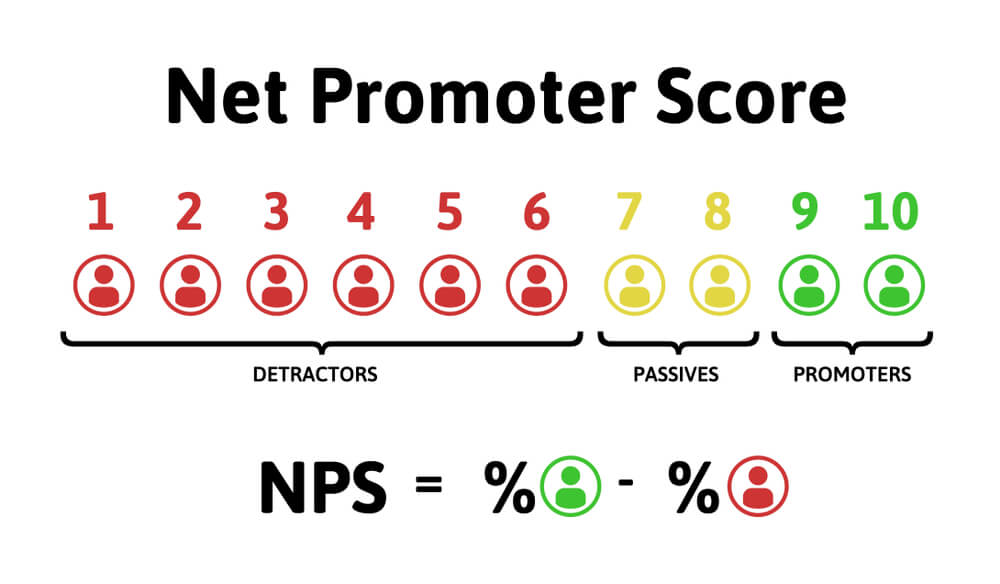

In [18]:
df_nps["nps_cat"] = pd.cut(df_nps["nps_score"],
                               bins=[-1,6 , 8, 10],
                               labels=[1, 2, 3])

In [19]:
print('nova associação, mas agora quanto relação das categoria do NPS')
nps_cat = df_nps.corr()['nps_cat'].sort_values(ascending=True)
nps_cat[:4]

nova associação, mas agora quanto relação das categoria do NPS


complaints_count            -0.443605
delivery_delay_days         -0.412236
customer_service_contacts   -0.246885
resolution_time_days        -0.158034
Name: nps_cat, dtype: float64

agora faremos uma analise utilizando as médias por grupos.<br>

In [20]:
#dataframe agrupado por categoria 
comparativo = df_nps.groupby('nps_cat',observed=False).mean()

o objetivo dessa analise é entender as maiores correlações entre os detratores  <br>
para isso iremos agrupar e faremos uma média de todos os dados, após isso iremos filtrar apenas os detratores [1]

In [21]:
perfil_detrator = comparativo.loc[1] / comparativo.median() 
perfil_detrator = perfil_detrator.sort_values(ascending=False)

print(perfil_detrator[:4])

delivery_delay_days          1.816590
complaints_count             1.547879
customer_service_contacts    1.500020
resolution_time_days         1.198866
dtype: float64


apenas para fim de estudos veremos as relações entre os promotores também

In [22]:
perfil_promotor = comparativo.loc[3] / comparativo.median() 
perfil_promotor = perfil_promotor.sort_values(ascending=False)

print(perfil_promotor[:4])

repeat_purchase_30d    26.352941
nps_score               1.319315
customer_region_Sul     1.211335
discount_value          1.068651
dtype: float64


#### <font size="5"> **Estudo de ruptura em contato do cliente** </font>

##### <font size="5">**Ruptura em numero de reclamações**</font>

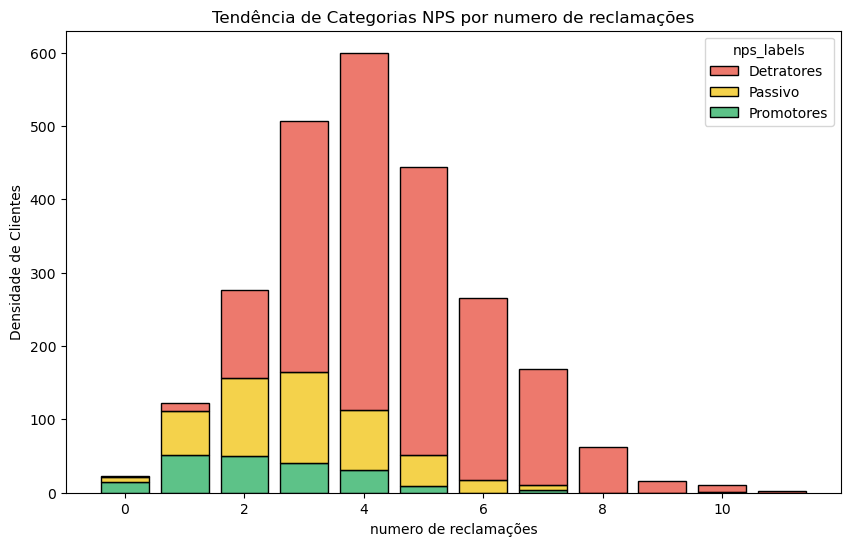

In [60]:
#histplot
gerar_hisplot(df_nps,'complaints_count')

> ao analisar a quantidade de reclamações é possivel notar uma tendencia de maior numero de detratores a partir da terceira reclamação 

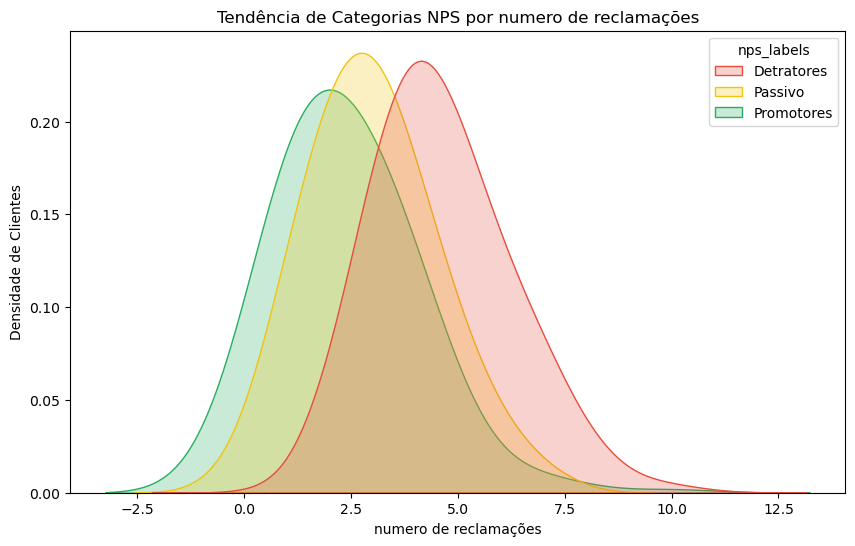

In [47]:
gerar_kdeplot(df_nps,'complaints_count')

> novamente identificamos um ponto de transição a partir de três reclamações,
aqui é onde o numero de detratores supera o numero de promotores e o ponto de ruptura aparenta ser a quarta reclamação,
onde o numero de promotores passa a ser substancialmente menor que o numero de detratores
vamos fazer agora uma analise percentual de nps por numero de reclamações

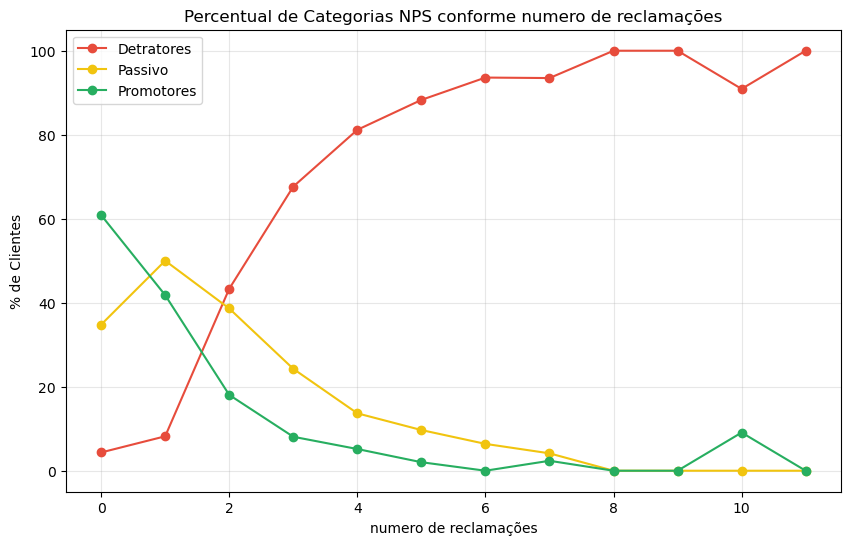

In [25]:
grafico_linhas_percentual(df_nps,'complaints_count')

> Em termos percentuais o numero de detratores supera os promotores a partir da segunda reclamação. 

##### <font size="5">**Ruptura em dias de atraso**</font>

faremos uma analise de contagem geral das categorias em relação ao dia de atrasos

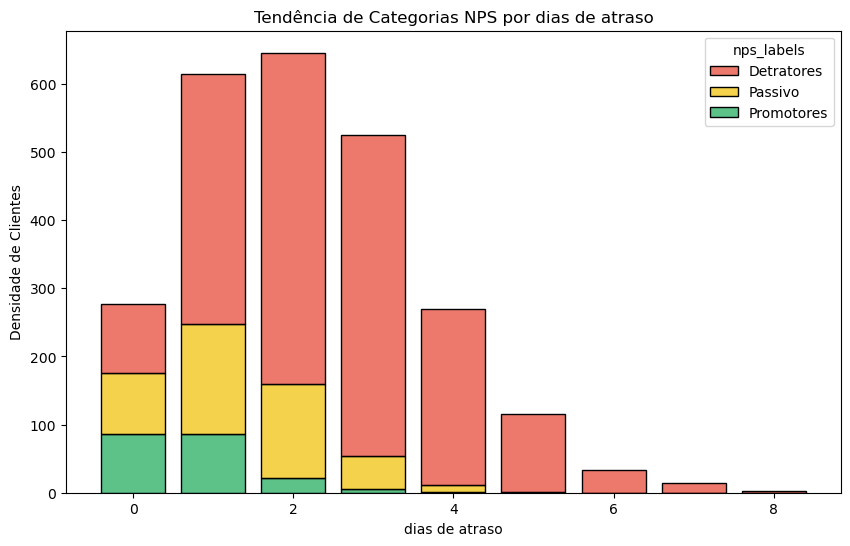

In [61]:
gerar_hisplot(df_nps,'delivery_delay_days')

podemos notar que a partir de 1 dia de atraso já temos um aumento substancial de detratores, e a partir do segundo dia de atraso o numero de promotores é quase nulo. 
agora vamos fazer uma analise de densidade 

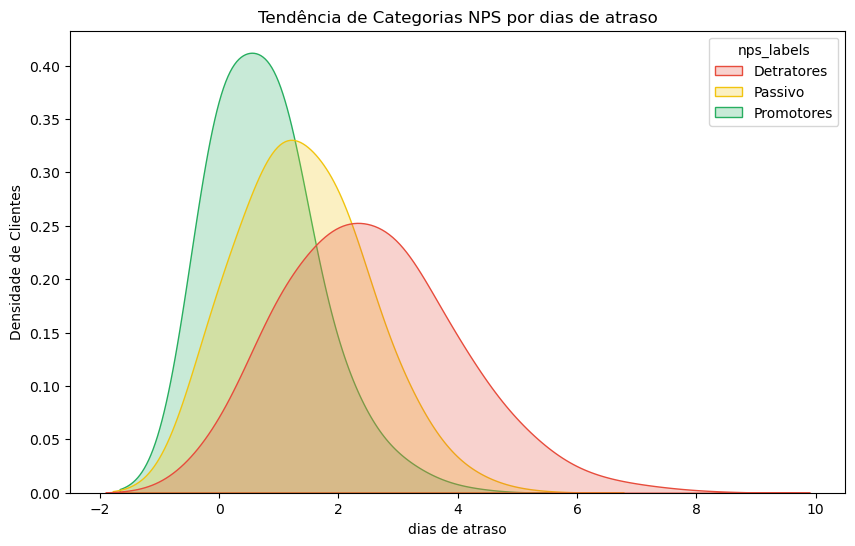

In [48]:
gerar_kdeplot(df_nps,'delivery_delay_days')

novamente identificamos um ponto de transição no segundo dia, aqui é onde o numero de detratores supera o numero de promotores e o ponto de ruptura aparenta ser o terceiro dia, onde o numero de promotores passa a ser bem baixo
vamos fazer agora uma analise percentual de nps por dia de atraso

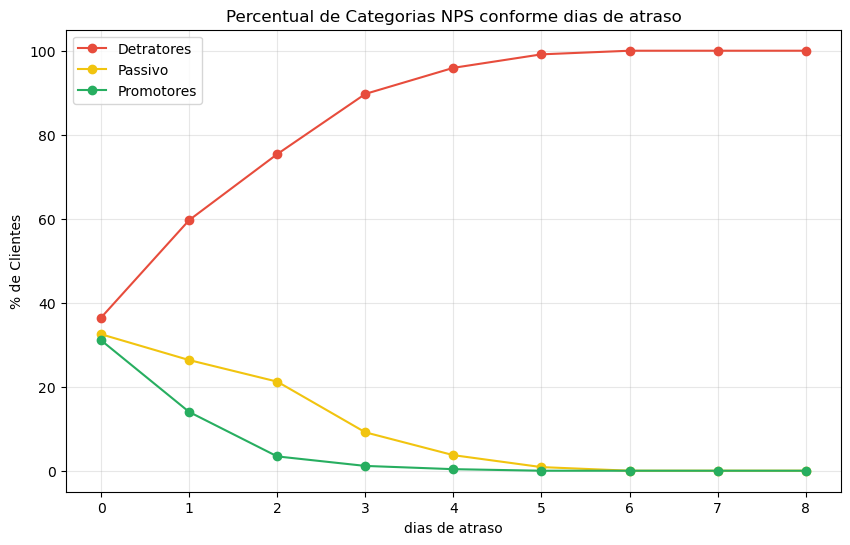

In [275]:
grafico_linhas_percentual(df_nps,'delivery_delay_days')

##### <font size="5">**Ruptura em numero de contatos**</font>

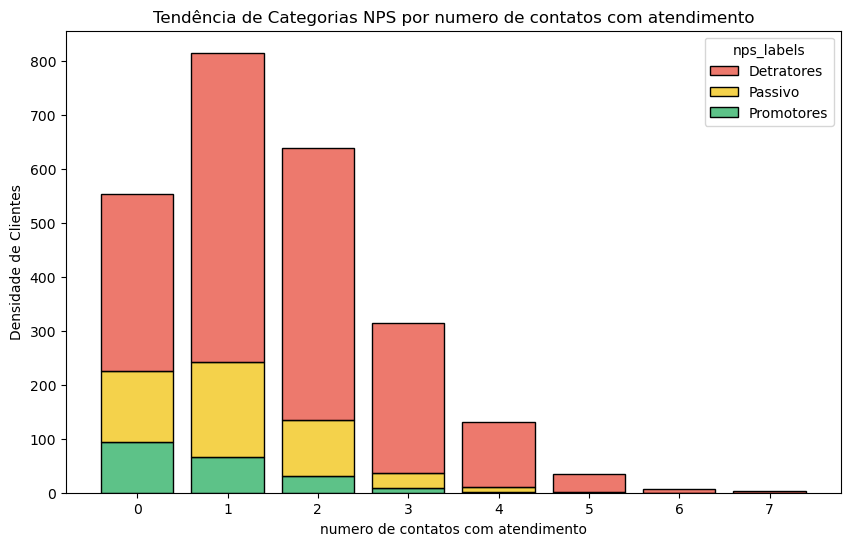

In [64]:
gerar_hisplot(df_nps,'customer_service_contacts')

Existe uma tendencia a detratores já no primeiro contato com nossa equipe de atendimento

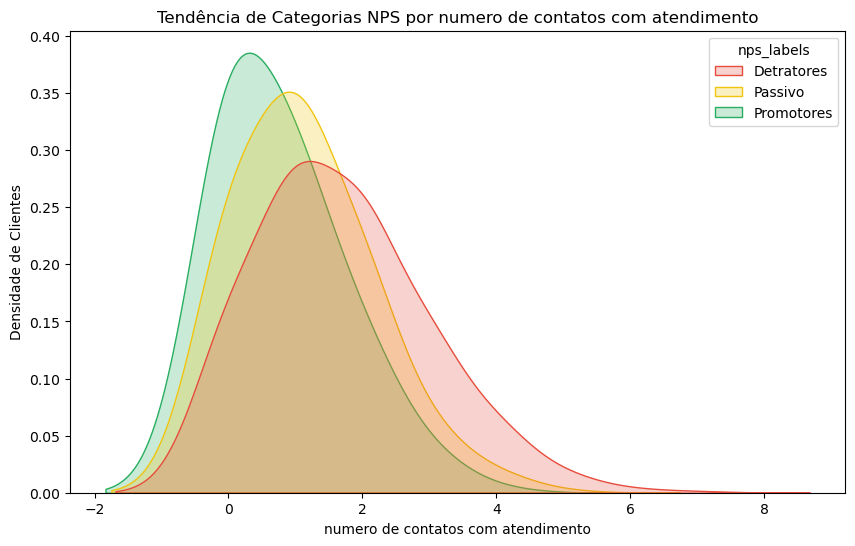

In [65]:
gerar_kdeplot(df_nps,'customer_service_contacts')

Podemos notar uma tendencia a promotores que entram em contato apenas uma vez com o SAC

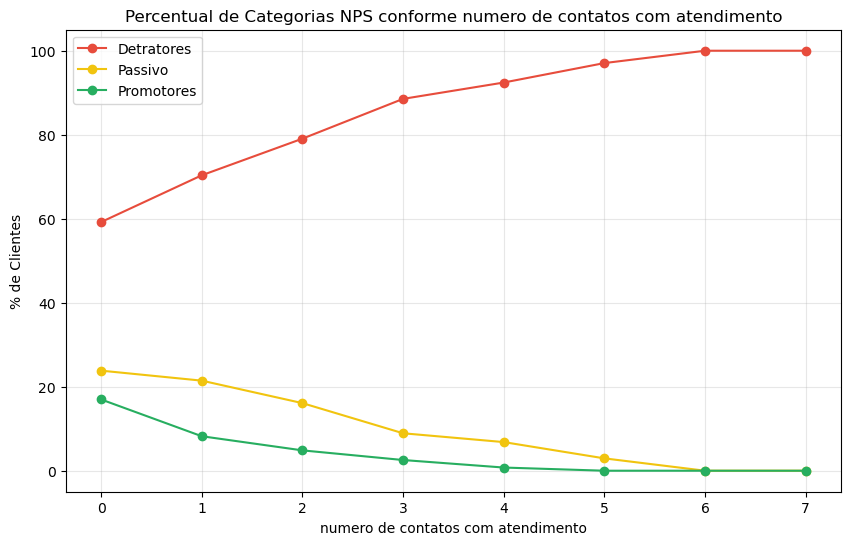

In [66]:
grafico_linhas_percentual(df_nps,'customer_service_contacts')

existe uma forte tendencia a detratores até mesmo antes de entrar em contato com atendimento. E conseguimos manter um percentual de passivos e promotores em torno de 40% se conseguirmos resolver o problema antes do segundo contato.

Vamos avaliar agora a ultima variavel com forte correlação

##### <font size="5">**Ruptura em em dias para a resolução de problemas**</font>

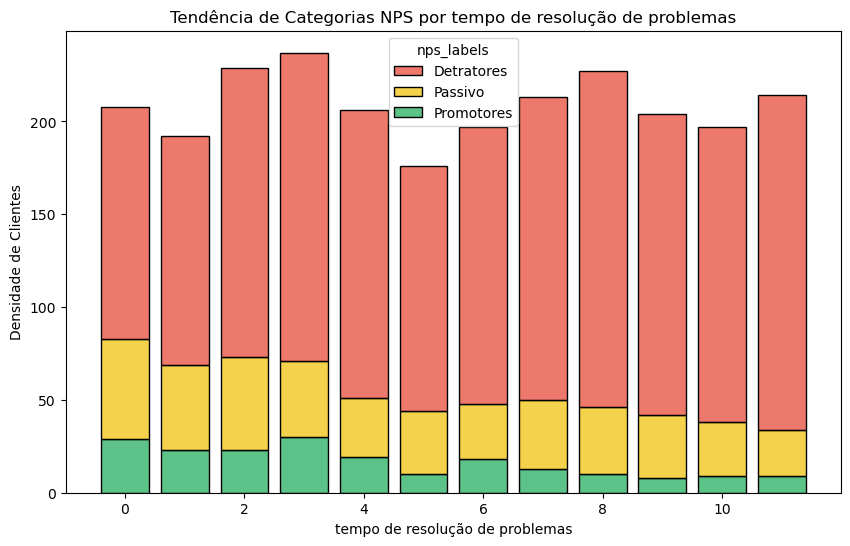

In [69]:
gerar_hisplot(df_nps,'resolution_time_days')

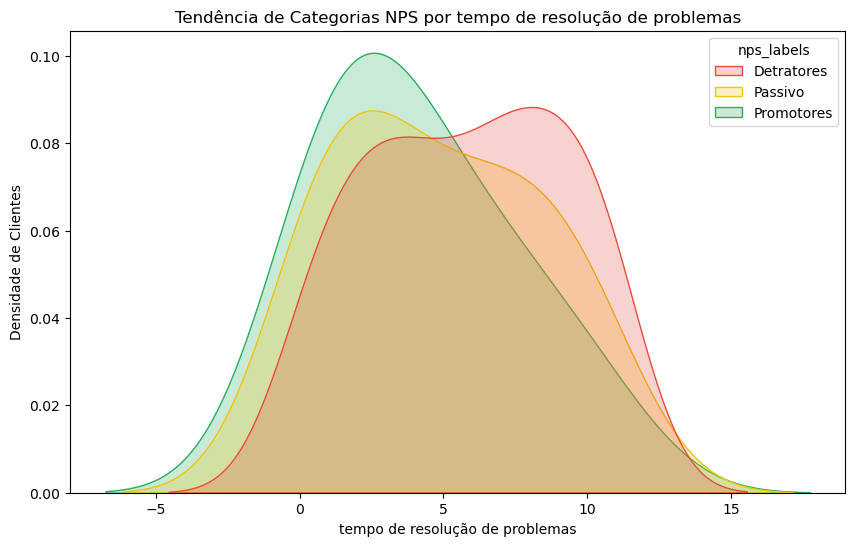

In [70]:
gerar_kdeplot(df_nps,'resolution_time_days')

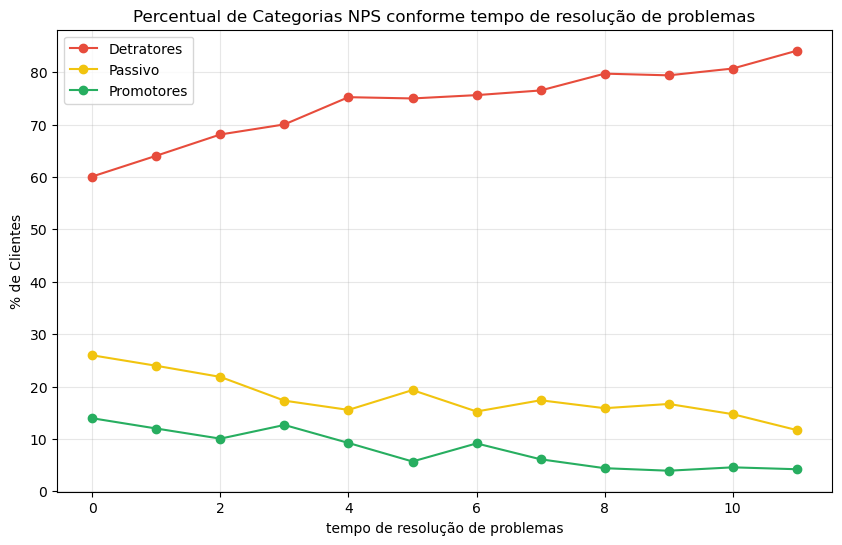

In [71]:
grafico_linhas_percentual(df_nps,'resolution_time_days')

Existe uma maior tendencia a se tornar detrator a partir de um atraso de 4 antes da resolução do problema   

#### <font size="6"> **Conclusão sobre os pontos de ruptura:** </font> <br>
**é possivel chegar a algumas hipóteses:** <br>
> a partir da terceira reclamação os clientes tem maior chance de se tornarem detratores<br>
> a partir do segundo dia de atraso os clientes tem maior probabilidade de se tornarem detratores <br>
> a partir do segundo contato existe maior probabilidade dos clientes se tornarem detratores <br>
> a partir do terceiro dia sem a resolução de problemas, existe uma maior probabilidade do cliente se tornar detrator <br>

#### <font size="5"> **Estudo de hipoteses** </font>

In [147]:
from scipy.stats import mannwhitneyu

def teste_mann_w_u(grupo_1, grupo_2,h0="",alpha=0.05 ):
    stat, p_value = mannwhitneyu(grupo_1, grupo_2, alternative='two-sided')

    
    print(f"Estatística U: {stat}")
    print(f"p-valor: {p_value}")
    
    if p_value < alpha:
        print('Resultado: Há diferença simgnificativa.')
        print(f"Rejeitamos a hipótese nula (H0): {h0}")
        
    else:
        print('Resultado: Não há diferença significativa.')
        print(f"Não rejeitamos a hipótese nula (H0). {h0} ")

##### <font size="5">h1 = a partir da terceira reclamação os clientes tem maior chance de se tornarem detratores</font>

In [136]:
hipotese_nula_reclamacoes = 'NPS se mantem igual com menos de três reclamações'
reclamacoes_h0 = df_nps[df_nps['complaints_count'] < 3]['nps_score']
reclamacoes_h1= df_nps[df_nps['complaints_count'] >= 3]['nps_score']

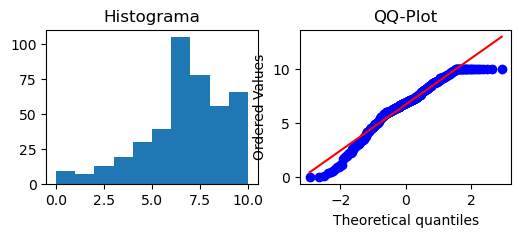

Média da amostra: 6.683
IC Bootstrap (95%): 6.476  a  6.894
p-valor Shapiro-Wilk: 0.0000 (não normal)


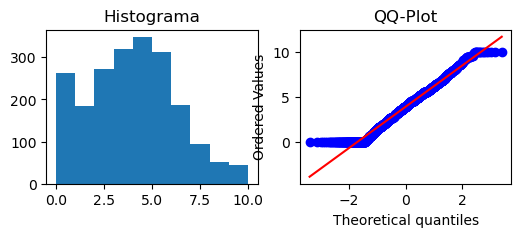

Média da amostra: 3.911
IC Bootstrap (95%): 3.814  a  4.011
p-valor Shapiro-Wilk: 0.0000 (não normal)


In [131]:
analyze_distribution_and_ci(reclamacoes_h0)
analyze_distribution_and_ci(reclamacoes_h1)

In [137]:
teste_mann_w_u(reclamacoes_h0,reclamacoes_h1,hipotese_nula_reclamacoes)

Estatística U: 713910.5
p-valor: 2.558867076207088e-92
Resultado: Há diferença significativa.
Rejeitamos a hipótese nula (H0): NPS se mantem igual com menos de três reclamações


##### <font size="5">h1 = a partir do 2º dia de atraso os clientes tem maior probabilidade de se tornarem detratores </font>

In [142]:
hipotese_nula_atraso = 'NPS se mantem igual com até dois dias de atraso'
atraso_h0 = df_nps[df_nps['delivery_delay_days'] < 3]['nps_score']
atraso_h1= df_nps[df_nps['delivery_delay_days'] >= 3]['nps_score']

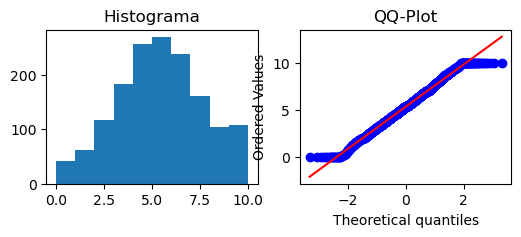

Média da amostra: 5.376
IC Bootstrap (95%): 5.263  a  5.489
p-valor Shapiro-Wilk: 0.0000 (não normal)


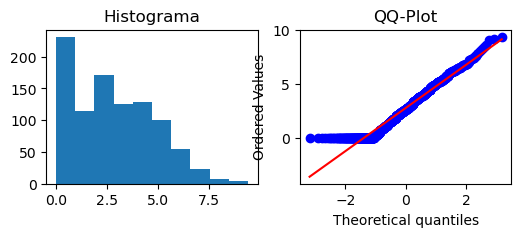

Média da amostra: 2.783
IC Bootstrap (95%): 2.656  a  2.912
p-valor Shapiro-Wilk: 0.0000 (não normal)


In [143]:
analyze_distribution_and_ci(atraso_h0)
analyze_distribution_and_ci(atraso_h1)

In [144]:
teste_mann_w_u(atraso_h0,atraso_h1,hipotese_nula_atraso)

Estatística U: 1183034.0
p-valor: 1.224521170143194e-140
Resultado: Há diferença significativa.
Rejeitamos a hipótese nula (H0): NPS se mantem igual com até dois dias de atraso


##### <font size="5">h1 = a partir do segundo contato existe maior probabilidade dos clientes se tornarem detratores</font>

In [138]:
hipotese_nula_contatos = 'Não há alteração no NPS com menos de dois contatos com o SAC'
contatos_h0 = df_nps[df_nps['customer_service_contacts'] < 2]['nps_score']
contatos_h1 = df_nps[df_nps['customer_service_contacts'] >= 2]['nps_score']

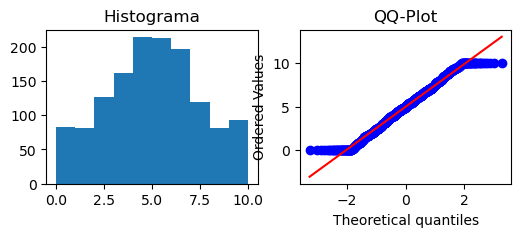

Média da amostra: 5.016
IC Bootstrap (95%): 4.885  a  5.142
p-valor Shapiro-Wilk: 0.0000 (não normal)


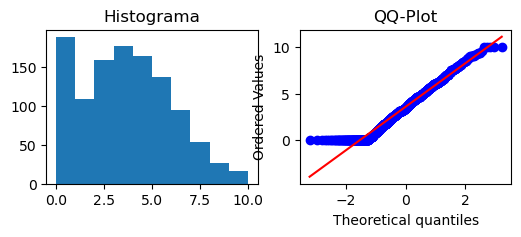

Média da amostra: 3.606
IC Bootstrap (95%): 3.468  a  3.749
p-valor Shapiro-Wilk: 0.0000 (não normal)


In [117]:
analyze_distribution_and_ci(contatos_h0)
analyze_distribution_and_ci(contatos_h1)

In [139]:
teste_mann_w_u(contatos_h0,contatos_h1,hipotese_nula_contatos)

Estatística U: 1021819.5
p-valor: 2.677195218819886e-43
Resultado: Há diferença significativa.
Rejeitamos a hipótese nula (H0): Não há alteração no NPS com menos de dois contatos com o SAC


##### <font size="5">h1 = a partir do terceiro dia sem a resolução de problemas, existe uma maior probabilidade do cliente se tornar detrator </font>

In [148]:
hipotese_nula_resolucao = 'Não há alteração no NPS com menos de dois resolucao de problemas'
resolucao_h0 = df_nps[df_nps['resolution_time_days'] < 3]['nps_score']
resolucao_h1 = df_nps[df_nps['resolution_time_days'] >= 3]['nps_score']

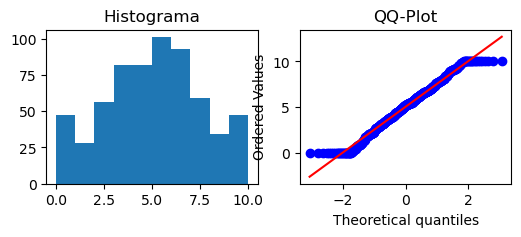

Média da amostra: 5.041
IC Bootstrap (95%): 4.847  a  5.245
p-valor Shapiro-Wilk: 0.0000 (não normal)


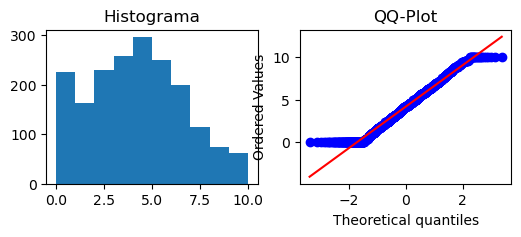

Média da amostra: 4.156
IC Bootstrap (95%): 4.045  a  4.265
p-valor Shapiro-Wilk: 0.0000 (não normal)


In [149]:
analyze_distribution_and_ci(resolucao_h0)
analyze_distribution_and_ci(resolucao_h1)

In [150]:
teste_mann_w_u(resolucao_h0,resolucao_h1,hipotese_nula_resolucao)

Estatística U: 708017.5
p-valor: 2.217160622719586e-14
Resultado: Há diferença simgnificativa.
Rejeitamos a hipótese nula (H0): Não há alteração no NPS com menos de dois resolucao de problemas


#### <font size="6"> **Conclusão das hipoteses:** </font> <br>
**Nossas hipoteses foram validadas** <br>

Para mentermos o NPS alto precisamos evitar mais de duas reclamações, não atrasar mais de um dia, resolver os problemas no primeiro contato dos clientes e em até dois dias após o contato

In [168]:
dataset = df_nps[['nps_cat','delivery_delay_days','customer_service_contacts','complaints_count','resolution_time_days','repeat_purchase_30d']]

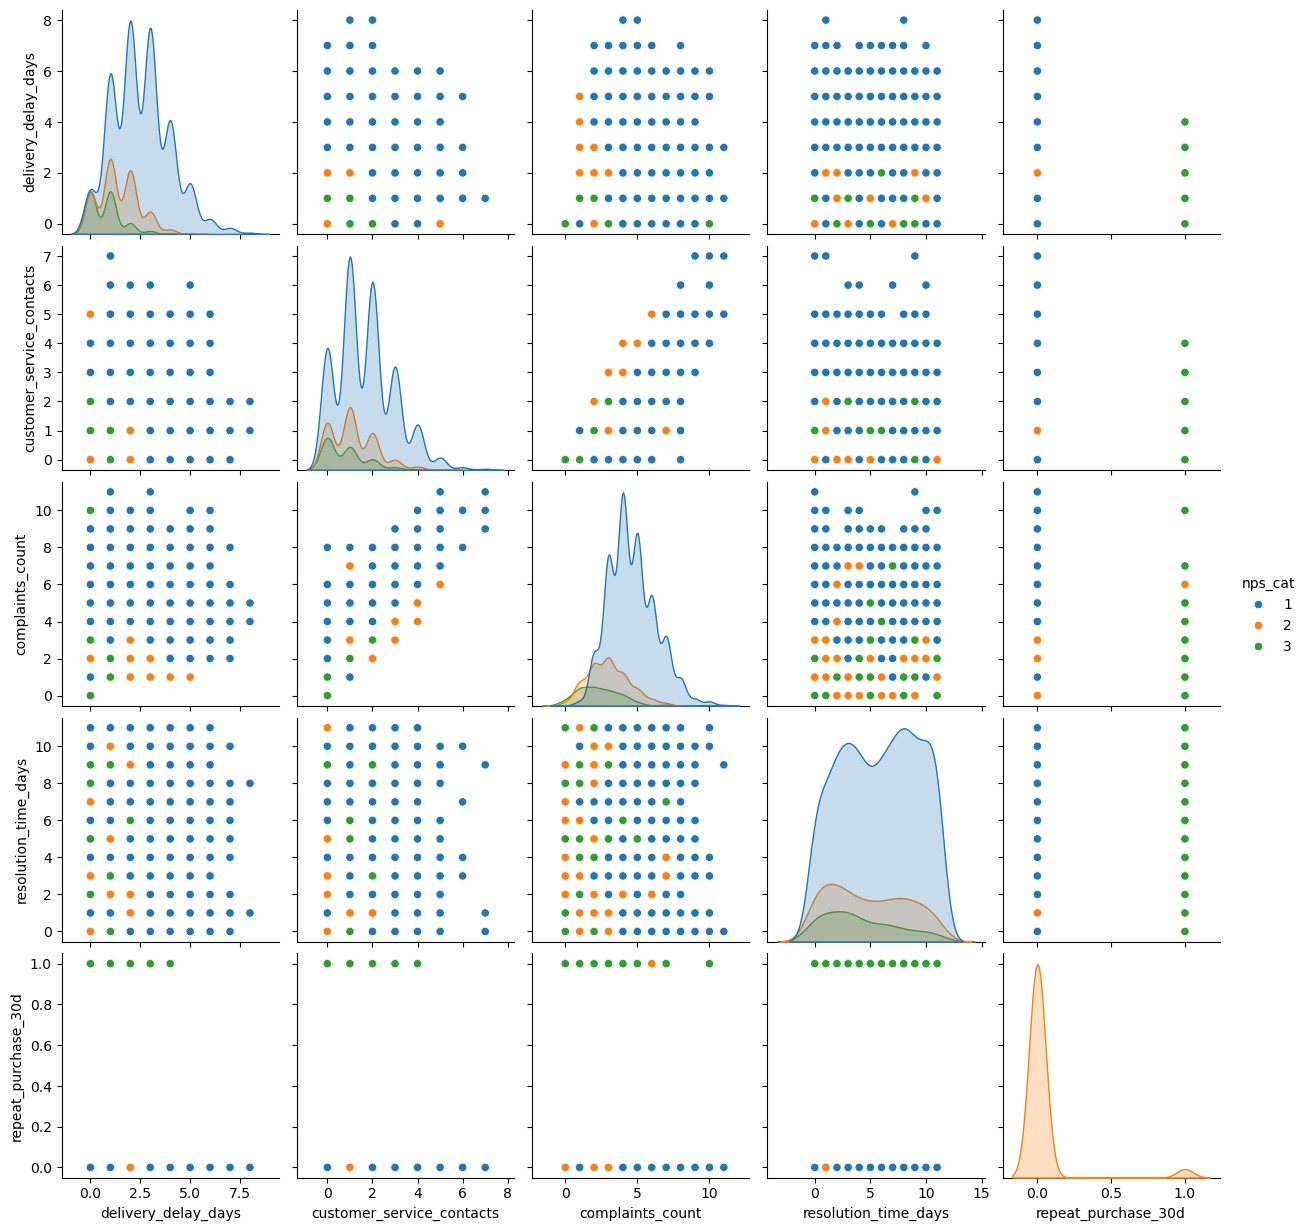

In [169]:
sns.pairplot(dataset,hue='nps_cat')

In [173]:
df_regiao = df_nps[['nps_cat','delivery_delay_days','customer_region_Centro-Oeste','customer_region_Nordeste', 'customer_region_Norte','customer_region_Sudeste', 'customer_region_Sul']]

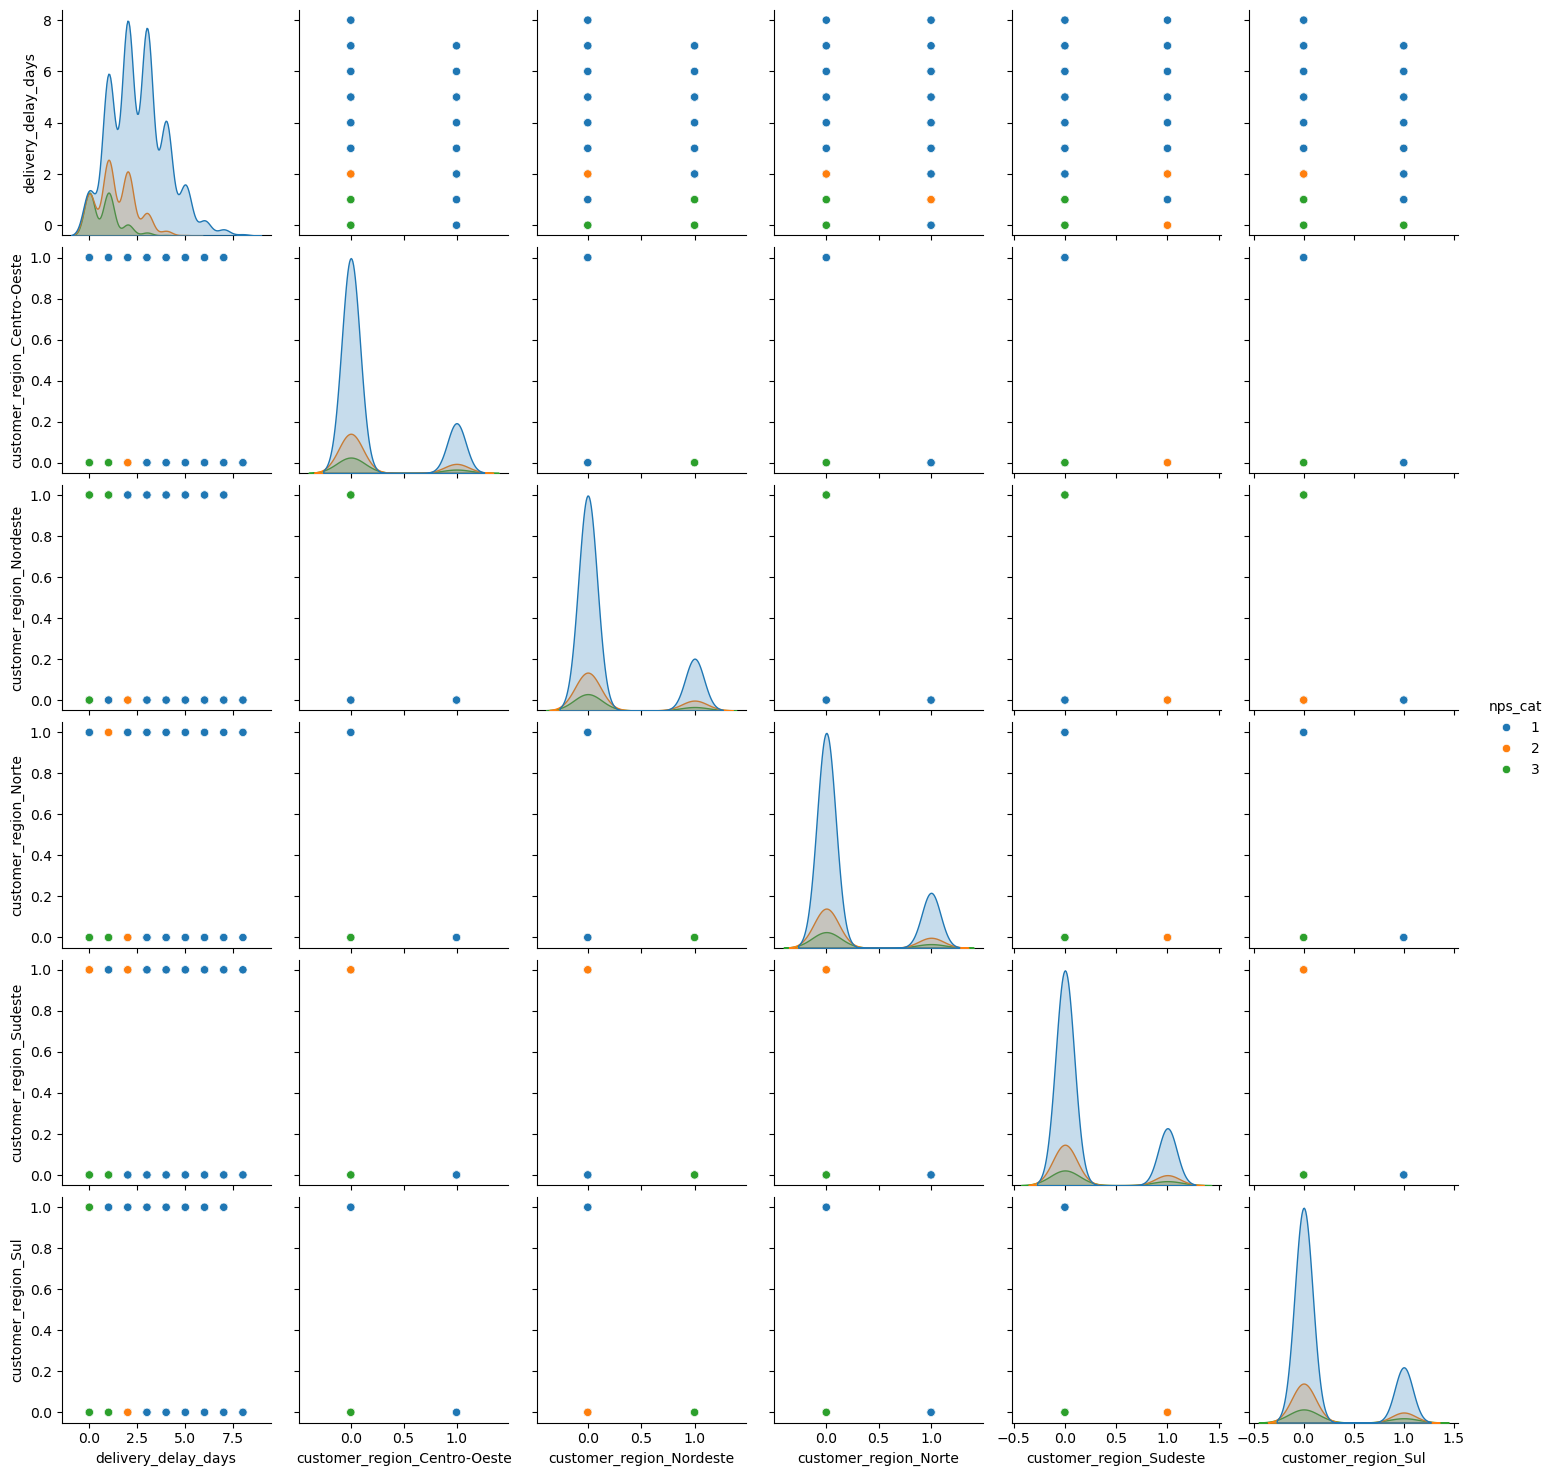

In [175]:
sns.pairplot(df_regiao,hue='nps_cat')

In [155]:
comparativo#.loc[1]

,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,...,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,customer_region_Centro-Oeste,customer_region_Nordeste,customer_region_Norte,customer_region_Sudeste,customer_region_Sul
nps_cat,,,,,,,,,,,,,,,,,,,,,
1,43.309562,61.575365,51236.515937,428.985446,3.494868,29.631248,5.968125,7.995678,2.534306,38.401091,...,1.694219,5.793625,3.257699,0.000000,4.622907,0.188006,0.193949,0.203674,0.209616,0.204754
2,43.446429,59.506696,51306.098214,447.334554,3.352679,29.356808,6.191964,8.120536,1.395089,37.908058,...,1.129464,4.832589,6.893750,0.037946,2.986607,0.187500,0.205357,0.203125,0.198661,0.205357
3,44.079602,63.039801,51255.358209,453.688607,3.512438,31.665473,5.915423,8.044776,0.756219,37.210498,...,0.781095,4.104478,9.095025,1.000000,2.393035,0.179104,0.169154,0.189055,0.213930,0.248756


In [76]:
df_nps.head(2)

,customer_age,customer_tenure_months,order_id,order_value,items_quantity,discount_value,payment_installments,delivery_time_days,delivery_delay_days,freight_value,...,customer_service_contacts,resolution_time_days,nps_score,repeat_purchase_30d,complaints_count,customer_region_Centro-Oeste,customer_region_Nordeste,customer_region_Norte,customer_region_Sudeste,customer_region_Sul
0,63,14,50001,139.73,4,39.35,4,2,2,55.53,...,0,4,6.9,0,3,0.0,1.0,0.0,0.0,0.0
1,20,1,50002,458.95,2,9.51,10,6,4,28.23,...,0,10,2.4,0,3,0.0,0.0,0.0,0.0,1.0


In [ ]:
#MODELO DE REGRESSAO CLASSIFICANDO DA FORMA COMO QUISER

### 4. Como forma de preparação para as próximas fases do curso, este desafio propõe uma reflexão prática sobre como a Ciência de Dados pode ser utilizada para antecipar a satisfação do cliente.

In [113]:
print('variaveis com maior probabilidade de afetar a satisfação')
correlacoes[abs(correlacoes) > 0.15]

variaveis com maior probabilidade de afetar a satisfação


delivery_delay_days         -0.597260
complaints_count            -0.496800
customer_service_contacts   -0.350845
resolution_time_days        -0.191392
repeat_purchase_30d          0.570324
nps_score                    1.000000
Name: nps_score, dtype: float64

In [116]:
df_nps["nps_cat"] = pd.cut(df_nps["nps_score"],
                               bins=[-1,6 , 8, 10],
                               labels=[1, 2, 3])

print('relação quanto a definição de categoria do NPS')
nps_cat = df_nps.corr()['nps_cat'].sort_values(ascending=True)
nps_cat[abs(nps_cat) > 0.15]

relação quanto a definição de categoria do NPS


complaints_count            -0.443605
delivery_delay_days         -0.412236
customer_service_contacts   -0.246885
resolution_time_days        -0.158034
nps_score                    0.776244
repeat_purchase_30d          0.787841
nps_cat                      1.000000
Name: nps_cat, dtype: float64

delivery_delay_days          1.816590
complaints_count             1.547879
customer_service_contacts    1.500020
resolution_time_days         1.198866
dtype: float64


In [11]:
sorted(list(df.columns))

['complaints_count',
 'csat_internal_score',
 'customer_age',
 'customer_id',
 'customer_region',
 'customer_service_contacts',
 'customer_tenure_months',
 'delivery_attempts',
 'delivery_delay_days',
 'delivery_time_days',
 'discount_value',
 'freight_value',
 'items_quantity',
 'nps_score',
 'order_id',
 'order_value',
 'payment_installments',
 'repeat_purchase_30d',
 'resolution_time_days']

In [31]:
df.parcelas_pagas_ate_3m.unique()

array([0, 2, 3, 1], dtype=int64)

In [34]:
df_estudo = df[['nps_score','customer_service_contacts']].copy()
df_estudo.groupby('customer_service_contacts').mean().round(2).T

customer_service_contacts,0,1,2,3,4,5,6,7
nps_score,5.54,4.66,4.12,3.2,2.65,2.24,0.74,1.2


In [35]:
atraso = df[['nps_score','delivery_delay_days']].copy()
atraso.groupby('delivery_delay_days').mean().round(2).sort_values(by="nps_score",ascending=False).T

delivery_delay_days,0,1,2,3,4,5,6,7,8
nps_score,6.86,5.55,4.58,3.44,2.44,1.48,1.1,0.29,0.0


In [39]:
contatos = df[['nps_score','customer_service_contacts']].copy()
contatos.groupby('customer_service_contacts').mean().round(2).sort_values(by="nps_score",ascending=False).T

customer_service_contacts,0,1,2,3,4,5,7,6
nps_score,5.54,4.66,4.12,3.2,2.65,2.24,1.2,0.74


In [45]:
teste = df[['nps_score','csat_internal_score']].copy()
teste.groupby('csat_internal_score').mean().round(2).sort_values(by="nps_score",ascending=False).T

csat_internal_score,9.9,9.5,9.2,9.1,9.7,8.3,9.4,10.0,9.3,8.6,...,0.6,0.8,0.3,1.6,0.4,0.5,0.7,0.2,0.1,0.0
nps_score,10.0,10.0,10.0,10.0,9.2,9.15,9.15,8.85,8.7,8.38,...,3.73,3.46,3.46,3.43,3.4,3.37,3.25,3.2,2.97,2.09


In [43]:
teste = df[['nps_score','complaints_count']].copy()
teste.groupby('complaints_count').mean().round(2).sort_values(by="nps_score",ascending=False).T

complaints_count,0,1,2,3,4,5,6,7,9,10,8,11
nps_score,8.52,7.77,6.05,4.91,4.22,3.65,3.06,2.81,2.49,2.28,2.07,0.85


In [44]:
teste = df[['csat_internal_score','complaints_count']].copy()
teste.groupby('complaints_count').mean().round(2).sort_values(by="csat_internal_score",ascending=False).T

complaints_count,0,1,2,3,4,5,9,6,7,8,10,11
csat_internal_score,6.36,5.07,4.22,3.35,2.92,2.4,2.16,1.89,1.64,1.21,1.16,1.15


In [46]:
df.nps_score.unique()

array([ 6.9,  2.4,  4.8,  5.9,  6.1,  0.9,  1.4,  0. ,  6.2,  2.7,  5.3,
        7. ,  3.7,  2.9,  6. ,  1.9,  3.4,  2. ,  5.7, 10. ,  3.3,  3.2,
        5.1,  9.1,  0.3,  3.8,  4.2,  4.9,  6.8,  4.4,  1.8,  5.6,  2.6,
        4.5,  2.3,  0.7,  6.6,  0.6,  3.9,  5.8,  4. ,  0.4,  8.4,  3.1,
        2.1,  7.9,  5.4,  9.6,  7.6,  7.5,  3.6,  5. ,  4.6,  4.1,  1.1,
        6.4,  1.6,  6.3,  1.7,  9.4,  6.5,  9. ,  3.5,  7.8,  0.8,  2.2,
        8.8,  9.2,  7.7,  6.7,  7.2,  2.8,  4.3,  7.3,  1. ,  5.2,  5.5,
        9.8,  8.1,  8.3,  1.5,  2.5,  0.2,  0.5,  8.5,  3. ,  8. ,  4.7,
        1.2,  7.1,  7.4,  0.1,  8.2,  8.6,  1.3,  9.5,  8.9,  9.9,  9.3,
        8.7,  9.7])

In [66]:
df_estudo = df[['complaints_count','nps_score','classificacao_nps','csat_internal_score','delivery_delay_days','customer_service_contacts','order_value']]

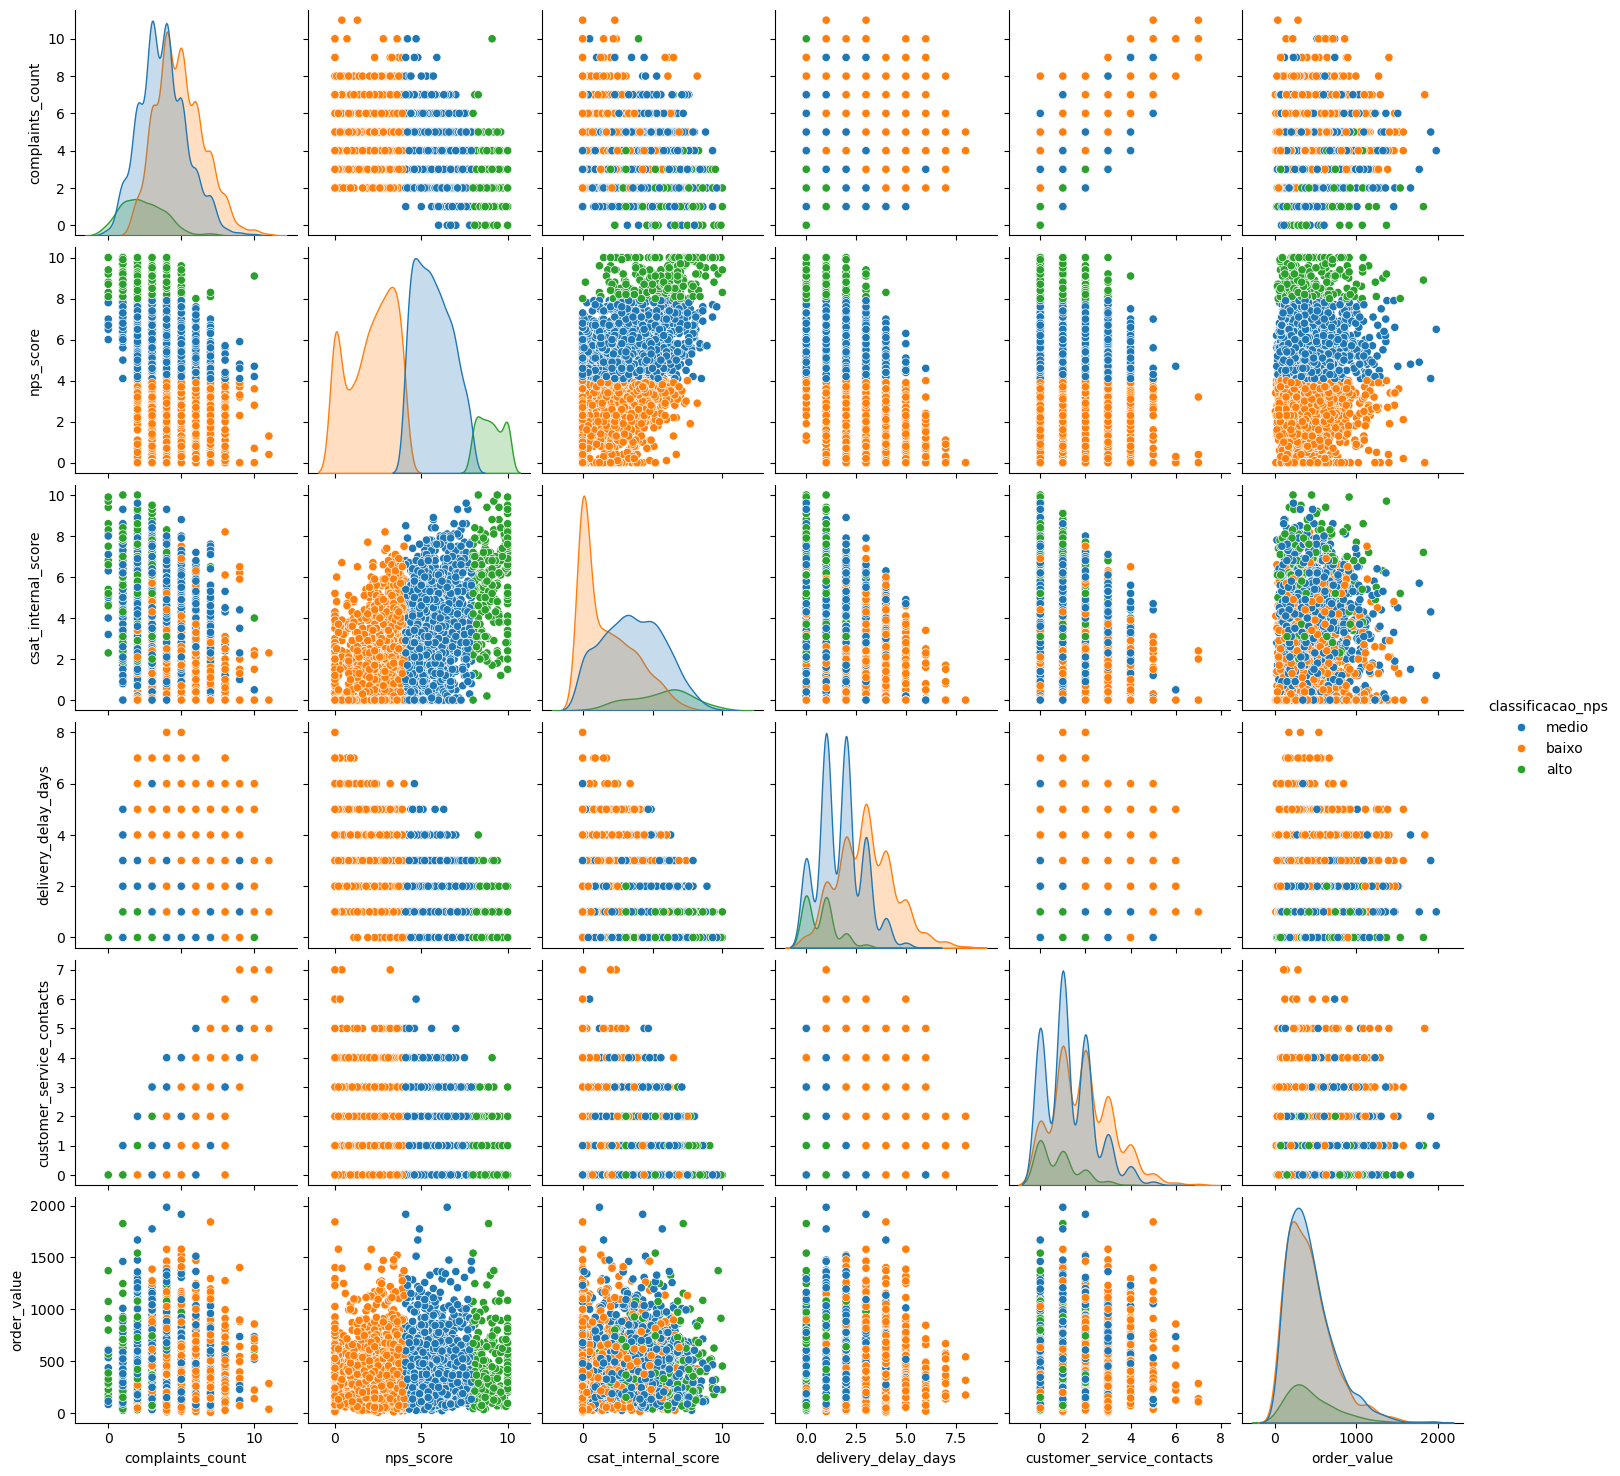

In [67]:
sns.pairplot(df_estudo,hue='classificacao_nps')

In [68]:
df_estudo.describe()

,complaints_count,nps_score,csat_internal_score,delivery_delay_days,customer_service_contacts,order_value
count,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,4.150400,4.378600,2.941600,2.187200,1.519600,434.259740
std,1.784223,2.510229,2.378957,1.454442,1.231512,289.772497
min,0.000000,0.000000,0.000000,0.000000,0.000000,7.760000
25%,3.000000,2.600000,0.700000,1.000000,1.000000,220.245000
50%,4.000000,4.400000,2.800000,2.000000,1.000000,375.515000
75%,5.000000,6.100000,4.800000,3.000000,2.000000,577.290000
max,11.000000,10.000000,10.000000,8.000000,7.000000,1983.810000


In [74]:
dataframe = dataframe[['nps_score','']]

,complaints_count,nps_score,csat_internal_score,delivery_delay_days,customer_service_contacts,order_value
classificacao_nps,,,,,,
alto,2.422018,9.009633,5.578440,0.756881,0.798165,456.234358
baixo,4.904635,2.109893,1.748663,2.980392,1.903743,426.624840
medio,3.745690,5.702672,3.599914,1.688793,1.283621,437.514819


# avaliacão distribuição Normal

<Axes: >

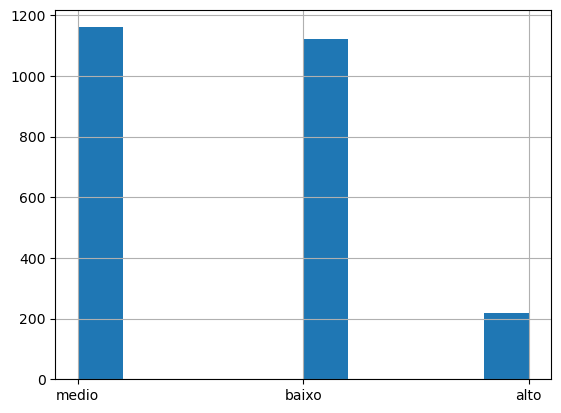

In [9]:
df['classificacao_nps'].hist()

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import shapiro, probplot

In [23]:
import matplotlib.pyplot as plt
from scipy.stats import shapiro, probplot

def analyze_distribution_and_ci(data, confidence=0.95, n_bootstrap=5000):
    data = np.array(data)
    n = len(data)
    mean = np.mean(data)

    # Teste Shapiro-Wilk para normalidade
    shapiro_stat, shapiro_p = shapiro(data)

    # Plot histograma
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.hist(data, bins=10)
    plt.title("Histograma")

    # QQ-Plot
    plt.subplot(1, 2, 2)
    probplot(data, dist="norm", plot=plt)
    plt.title("QQ-Plot")
    plt.show()

    # Bootstrap CI
    alpha = 1 - confidence
    boot_means = []
    
    for _ in range(n_bootstrap):
        sample = np.random.choice(data, size=n, replace=True)
        boot_means.append(np.mean(sample))

    lower = np.percentile(boot_means, (alpha/2) * 100)
    upper = np.percentile(boot_means, (1 - alpha/2) * 100)
    ci_bootstrap = (lower, upper)

    print(f"Média da amostra: {mean:.3f}")
    print(f"IC Bootstrap ({confidence*100:.0f}%): {ci_bootstrap[0]:.3f}  a  {ci_bootstrap[1]:.3f}")
    print(f"p-valor Shapiro-Wilk: {shapiro_p:.4f} {'(normal)' if shapiro_p>0.05 else '(não normal)'}")


In [24]:
shapiro_stat, shapiro_p = shapiro(np.array(df['nps_score']))

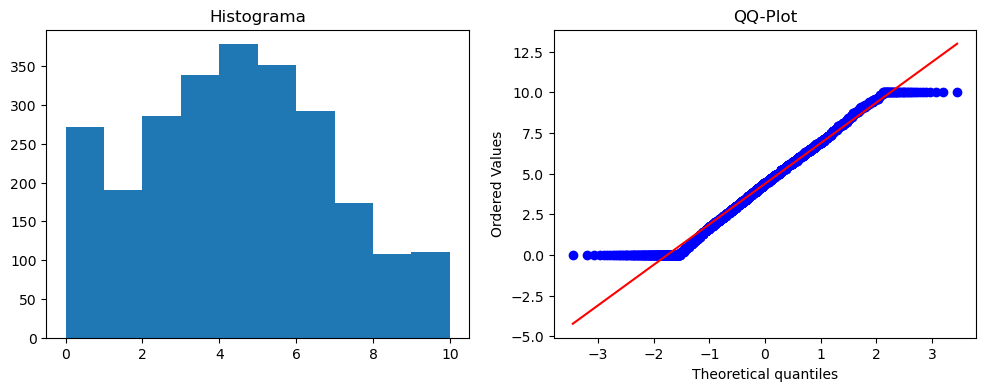

Média da amostra: 4.379
IC Bootstrap (95%): 4.281  a  4.476
p-valor Shapiro-Wilk: 0.0000 (não normal)


In [25]:
analyze_distribution_and_ci(np.array(df['nps_score']))